In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
from iminuit import Minuit, cost
from scipy.stats import genextreme


colors = {
    'VWLS':      '#DC2626',
    'MLE':       '#2563EB',
    'PWM':       '#16A34A',
    'L-moments': '#D97706',
}

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')


save_figures = True

In [6]:
# Load Data
filename="gev-mu=70,alpha=10,gamma=0.3,N=100000.csv"
directory = "data"
directory_figures="../Figures"
filepath = directory+ "/" + filename
print(f"Filepath: {filepath}")
df   = pd.read_csv(filepath)

data = np.array(df.values[:,0])
data;

Filepath: data/gev-mu=70,alpha=10,gamma=0.3,N=100000.csv


In [7]:
"""parameters"""

subset_n=10
subset = data[:subset_n]
#fit the data and get the parameters
mu=70
alpha=10
gamma=0.3

#take next random point and record bin [r-1,r], in which this point falls

#repeat this process until n_r/n does not change anymore



In [9]:
def x_in_bin_i(x,shape_param, mu_param, alpha_param):
    cdf_val = genextreme.cdf(x, c=-shape_param, loc=mu_param, scale=alpha_param)
    for r in range(0,subset_n):
        if weibull_p_m(r,subset_n)<cdf_val<=weibull_p_m(r+1,subset_n):
            return r
    return -1


def weibull_p_m(rank_m, n):
    """ rank_m >= 1
        n = number of data points in the subset"""
    p_m=rank_m / (n + 1)
    #print(f"P(m={rank_m},N={n}) = {p_m:.8f}")
    return p_m

In [ ]:

#take next random point and record bin [r-1,r], in which this point falls
bin=x_in_bin_i(data[subset_n+1],gamma, mu, alpha)

bin
#repeat this process until n_r/n does not change anymore


2

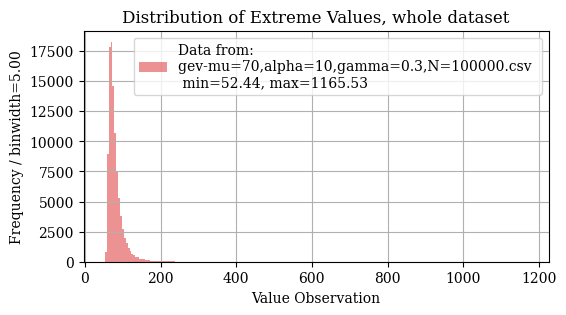

In [37]:
"""Histogram Plot"""

fig, ax = plt.subplots(1, 1, figsize=(6,3))

min_value = min(data)
max_value = max(data)
#n_bins = 50
bin_width = 5
n_bins = int((max_value - min_value) / bin_width)

ax.hist(data, bins=n_bins, density=False, range=(min_value,round(max_value,-1)), alpha=0.5, color=colors['VWLS'], label=f"Data from:\n{filename} \n min={min_value:.2f}, max={max_value:.2f}")
ax.set_xlabel("Value Observation")
ax.set_ylabel(f"Frequency / binwidth={bin_width:.2f}")
ax.set_title("Distribution of Extreme Values, whole dataset")
ax.grid()
ax.legend(loc="upper right")

if save_figures:
    fig.savefig(f"{directory_figures}/Hist_{filename}.png")